# Finding the Best k

In this activity, you’ll apply the elbow method to iteratively run the K-means algorithm and find the optimal number of clusters, or value for `k`.

Instructions

1. Read in  the `option_trades.csv` file from the Resources folder and create a DataFrame. Use the “date” column to create the DateTime Index. Be sure to include parameters for `parse_dates` and `infer_datetime_format`. 

    > **Note** The option data that’s provided for this activity contains the prices of options, measured every four hours, on various stock options on the S&P 500. These stock options differ by various characteristics, including the time to expiration.

2. Create two lists: one for the range of lowercase-k values (from 1 to 11) to analyze and another to hold the list of inertia scores.

3. For each instance of k, define and fit a K-means model, and append the model’s inertia to the empty inertia list that you created in Step 2.

4. Store the values for lowercase-k and the inertia lists in a DataFrame called `df_elbow_data`.

5. Using hvPlot, plot the `df_elbow_data` DataFrame to visualize the elbow curve. Be sure to style and format your plot. 

6. Answer the following question: Considering the plot, what’s the best number of clusters to choose, or value of k?

References

[scikit-learn Python Library](https://scikit-learn.org)

[scikit-learn ML Algorithms](https://scikit-learn.org/stable/user_guide.html)

[scikit-learn K-means](https://scikit-learn.org/stable/modules/clustering.html#k-means)



In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

## Step 1: Read in  the `option_trades.csv` file from the Resources folder and create a DataFrame. Use the “date” column to create the DateTime Index. Be sure to include parameters for `parse_dates` and `infer_datetime_format`. 

In [2]:
df_options = pd.read_csv(Path('10.3/01-Finding_the_Best_k/Resources/option_trades.csv'),
                         index_col = 'date',
                         parse_dates = True
                        )
df_options.head()

,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
date,,,,,,,,,,,,,,,,,,,,,
2020-08-04 08:30:00,195.631965,210.025058,202.829513,221.569809,215.823048,212.112938,197.524908,214.564618,207.460115,209.855990,...,212.817158,201.262083,213.933774,206.132907,219.661568,204.972118,199.161883,194.000531,201.362749,205.688881
2020-08-04 11:00:00,218.833616,193.663638,182.807302,213.005657,194.657965,216.787274,201.662100,215.953316,201.586270,204.233793,...,218.560756,203.906526,196.645644,189.943663,196.537013,215.602311,217.919553,195.033360,202.346823,209.713289
2020-08-04 15:00:00,222.549239,200.632362,204.053803,198.749230,193.896719,201.005404,199.516591,209.182859,205.425138,197.457472,...,202.110909,219.896820,189.815097,198.069253,184.975622,198.668261,189.010191,204.879033,185.872788,196.961774
2020-08-05 08:30:00,177.901221,167.170212,178.674226,180.081992,197.030368,182.861254,182.138259,163.847409,175.976501,170.643134,...,173.560308,165.625163,177.090720,193.282793,187.996491,172.252274,183.706807,191.109464,179.242510,181.603642
2020-08-05 11:00:00,180.847294,186.696453,184.825757,180.116009,190.997511,177.779359,180.832512,173.574245,174.426271,148.636061,...,185.786780,171.388340,169.806288,168.503200,198.223226,183.767643,183.771038,203.553074,187.438263,155.905713


## Step 2: Create two lists: one for the range of lowercase-k values (from 1 to 11) to analyze and another to hold the list of inertia scores.

In [3]:
# Create a list for the range of k's to analyze in the elbow plot
# The range should be 1 to 11. 
k = list(range(1,11))

In [4]:
# Create an empty list to hold inertia scores
inertia = []

## Step 3: For each instance of k, define and fit a K-means model, and append the model’s inertia to the empty inertia list that you created in Step 2.

In [5]:
for i in k:
    model = KMeans(n_clusters = i, random_state = 0)
    model.fit(df_options)
    inertia.append(model.inertia_)
inertia

[10804651.95737489,
 3367798.734774582,
 1660546.9227245785,
 1247512.1525326865,
 935906.6738774019,
 800332.5808538421,
 723493.2392097011,
 698169.141516788,
 625182.1616840928,
 617406.8498242841]

## Step 4: Store the values for lowercase-k and the inertia lists in a DataFrame called `df_elbow_data`.

In [6]:
# Create a dictionary with the data to plot the Elbow curve
elbow_data = { 'k': k, 'inertia': inertia}

In [7]:
df_elbow_data = pd.DataFrame(elbow_data)
df_elbow_data

,k,inertia
0,1,1.080465e+07
1,2,3.367799e+06
2,3,1.660547e+06
3,4,1.247512e+06
4,5,9.359067e+05
5,6,8.003326e+05
6,7,7.234932e+05
7,8,6.981691e+05
8,9,6.251822e+05
9,10,6.174068e+05


## Step 5:  Using hvPlot, plot the `df_elbow_data` DataFrame to visualize the elbow curve. Be sure to style and format your plot.

<Axes: title={'center': 'Elbow Curve'}>

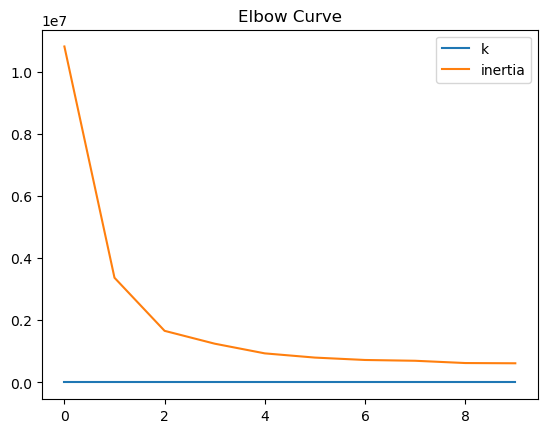

In [9]:
df_elbow_data.plot(title = 'Elbow Curve')

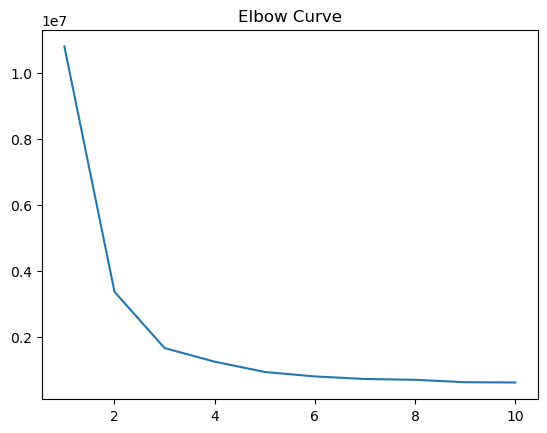

In [11]:
plt.title('Elbow Curve')
plt.plot(df_elbow_data['k'],df_elbow_data['inertia'])

## Step 6: Answer the following question:

**Question** Considering the plot, what’s the best number of clusters to choose, or value of k?

**Answer** Based on the plot, 3 seems to be the optimal number for k's value. 